#### Gaussian Naive Bayes

It is a kind of naive bayes algorithm that works with the continuous values.

##### Main aim of the algorithm:---

(a.)    The main aim of the algorithm is to predict the type of the Iris Plant Species using Gaussian Naive Bayes

(b.)    We can even improve the accuarcy of the model using Hyper Parameter Tuning with GridSearchCV



##### Step 1:  Import  all  the necessary libraries

In [892]:
import      numpy               as  np
import      pandas              as  pd
import      matplotlib.pyplot   as  plt
import      seaborn             as  sns

from        sklearn.datasets            import  load_iris
from        sklearn.model_selection     import  train_test_split, GridSearchCV, StratifiedKFold
from        sklearn.preprocessing       import  StandardScaler
from        sklearn.naive_bayes         import  GaussianNB
from        sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

#### Step 2: Load the Dataset

In [893]:
#### Construct the Data

data = load_iris()

#### Create the Dataframe from the data

df = pd.DataFrame(data.data, columns=data.feature_names)

#### Add the target to the dataframe

df['target'] = data.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### Step 3: Perform the Data Exploration

In [894]:
#### get the first five rows of the dataset

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [895]:
#### get the last five rows of the dataset

df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [896]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 150


In [897]:
#### Get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (150, 5)


In [898]:
#### get the columns used in the dataset

df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [899]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#### OBSERAVTIONS:

1.  All the independent features are floating in nature.

2.  The dependent feature ('target') is integer in nature.

In [900]:
#### get the correlation between all the columns in the dataset

df.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


<Axes: >

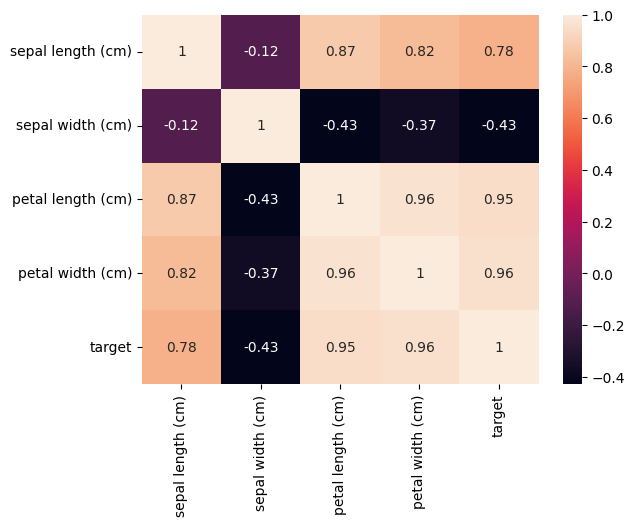

In [901]:
#### get the graphical representation between all the numerical columns in the dataset

sns.heatmap(df.corr(), annot=True)

#### Step 4: Perform Data Cleaning and Feature Engineering

In [902]:
#### To check for the NULL records in the dataset

df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [903]:
#### To check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
142,5.8,2.7,5.1,1.9,2


#### OBSERVATIONS:

1.  There is only one duplicate record in the dataset. So remove it.

In [904]:
#### Remove the duplicate record from the dataset

df = df.drop_duplicates()

In [905]:
#### To again check for the duplicate records in the dataset

df[df.duplicated()]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

In [906]:
#### Rename the columns to their proper names

df.rename(columns={"sepal length (cm)":"sepal_length" ,
                   "sepal width  (cm)" :"sepal_width" ,
                   "petal length (cm)" :"petal_length",
                   "petal width  (cm)" :"petal_width"}, inplace=True)

In [907]:
df.head()

,sepal_length,sepal width (cm),petal_length,petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### OBSERVATIONS:

1.  Now all the columns have been renamed to their proper column names.

In [908]:
### check the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 149


#### Step 5:  Divide the dataset into independent and dependent features

In [909]:
#### independent features

X = df.drop(columns='target', axis=1)

print(X)

     sepal_length  sepal width (cm)  petal_length  petal width (cm)
0             5.1               3.5           1.4               0.2
1             4.9               3.0           1.4               0.2
2             4.7               3.2           1.3               0.2
3             4.6               3.1           1.5               0.2
4             5.0               3.6           1.4               0.2
..            ...               ...           ...               ...
145           6.7               3.0           5.2               2.3
146           6.3               2.5           5.0               1.9
147           6.5               3.0           5.2               2.0
148           6.2               3.4           5.4               2.3
149           5.9               3.0           5.1               1.8

[149 rows x 4 columns]


In [910]:
#### dependent features

Y = df['target']

print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 149, dtype: int64


#### Step 6: Divide the independent and dependent features into training and testing data

In [911]:
from sklearn.model_selection    import  train_test_split

X_train, X_test, Y_train, Y_test  =   train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [912]:
X_train

,sepal_length,sepal width (cm),petal_length,petal width (cm)
6,4.6,3.4,1.4,0.3
128,6.4,2.8,5.6,2.1
95,5.7,3.0,4.2,1.2
44,5.1,3.8,1.9,0.4
30,4.8,3.1,1.6,0.2
...,...,...,...,...
52,6.9,3.1,4.9,1.5
47,4.6,3.2,1.4,0.2
102,7.1,3.0,5.9,2.1
124,6.7,3.3,5.7,2.1


In [913]:
X_test

,sepal_length,sepal width (cm),petal_length,petal width (cm)
69,5.6,2.5,3.9,1.1
66,5.6,3.0,4.5,1.5
141,6.9,3.1,5.1,2.3
7,5.0,3.4,1.5,0.2
147,6.5,3.0,5.2,2.0
57,4.9,2.4,3.3,1.0
84,5.4,3.0,4.5,1.5
28,5.2,3.4,1.4,0.2
138,6.0,3.0,4.8,1.8
127,6.1,3.0,4.9,1.8


In [914]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (119, 4)
Shape of the input testing  data is: (30, 4)


In [915]:
Y_train

6      0
128    2
95     1
44     0
30     0
      ..
52     1
47     0
102    2
124    2
16     0
Name: target, Length: 119, dtype: int64

In [916]:
Y_test

69     1
66     1
141    2
7      0
147    2
57     1
84     1
28     0
138    2
127    2
20     0
42     0
18     0
93     1
140    2
22     0
77     1
14     0
107    2
38     0
63     1
134    2
41     0
10     0
96     1
51     1
104    2
116    2
132    2
56     1
Name: target, dtype: int64

In [917]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (119,)
Shape of the output testing  data is: (30,)


#### Step 7:    Perform Feature Scaling on the inputs

In [918]:
from    sklearn.preprocessing  import  StandardScaler

#### create an object for Standard Scaler

sc = StandardScaler()

#### using the object of Standard Scaler, transform the inputs

X_train_scaled = sc.fit_transform(X_train)

X_test_scaled = sc.transform(X_test)

In [919]:
X_train_scaled

array([[-1.50158712,  0.7690314 , -1.33909259, -1.17973677],
       [ 0.63982407, -0.58674247,  1.04183404,  1.1863645 ],
       [-0.19294695, -0.13481785,  0.24819183,  0.00331387],
       [-0.90675068,  1.67288064, -1.05564894, -1.0482867 ],
       [-1.26365254,  0.09114446, -1.22571513, -1.31118684],
       [-0.43088152, -1.49059172,  0.02143691, -0.1281362 ],
       [ 0.63982407, -0.81270478,  0.87176786,  0.92346436],
       [ 0.52085678,  0.54306908,  1.26858896,  1.71216479],
       [ 2.18639882, -0.58674247,  1.66541007,  1.05491443],
       [ 1.59156238, -0.13481785,  1.1552115 ,  0.52911415],
       [-0.19294695,  3.02865451, -1.28240386, -1.0482867 ],
       [ 0.52085678, -0.36078016,  1.04183404,  0.79201429],
       [ 0.99672594,  0.54306908,  1.09852277,  1.71216479],
       [ 0.52085678, -0.58674247,  0.7583904 ,  0.39766408],
       [-0.43088152,  2.57672988, -1.33909259, -1.31118684],
       [ 0.87775865, -0.36078016,  0.47494675,  0.13476394],
       [-0.43088152, -1.

In [920]:
X_test_scaled

array([[-0.31191424, -1.26462941,  0.07812564, -0.1281362 ],
       [-0.31191424, -0.13481785,  0.41825802,  0.39766408],
       [ 1.23466052,  0.09114446,  0.7583904 ,  1.44926464],
       [-1.02571797,  0.7690314 , -1.28240386, -1.31118684],
       [ 0.75879136, -0.13481785,  0.81507913,  1.05491443],
       [-1.14468525, -1.49059172, -0.26200673, -0.25958627],
       [-0.54984881, -0.13481785,  0.41825802,  0.39766408],
       [-0.78778339,  0.7690314 , -1.33909259, -1.31118684],
       [ 0.16395492, -0.13481785,  0.58832421,  0.79201429],
       [ 0.28292221, -0.13481785,  0.64501294,  0.79201429],
       [-0.54984881,  0.7690314 , -1.1690264 , -1.31118684],
       [-1.7395217 ,  0.31710677, -1.39578132, -1.31118684],
       [-0.19294695,  1.67288064, -1.1690264 , -1.17973677],
       [-1.02571797, -1.71655403, -0.26200673, -0.25958627],
       [ 0.99672594,  0.09114446,  1.04183404,  1.58071472],
       [-1.50158712,  1.22095602, -1.56584751, -1.31118684],
       [ 0.99672594, -0.

#### OBSERVATIONS:

1.  After performing the feature scaling on the inputs , all the features have been converted in the same scale range of inputs between -1 to 1.

#### Step 8:    Train   the     Gaussian    Naive Bayes Model

In [921]:
from    sklearn.naive_bayes     import  GaussianNB


####  Create an object for Gaussian Naive Bayes

gnb =   GaussianNB()

#### Using the object for Gaussian Naive Bayes, train the model

gnb.fit(X_train_scaled, Y_train)

GaussianNB()

#### Step 9:    Predict the Gaussian Naive Bayes Model

In [922]:
Y_pred  =   gnb.predict(X_test_scaled)

In [923]:
Y_pred

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

#### Step 10:   Evaluate the Classification Metrics

In [924]:
from        sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

ac = accuracy_score(Y_test, Y_pred)*100.0

print("Accuracy score of the model is:", ac)



print("===============================Confusion matrix=======================================================")

cm = confusion_matrix(Y_test, Y_pred)

print("Confusion matrix of the model is:", cm)



print("===============================Classification report=======================================================")

cr = classification_report(Y_test, Y_pred)

print("Classification report of the model is:", cr)

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.33333333333333
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of Iris Plant Species data using Gaussian Naive Bayes Algorithm is 93.33. It is very high and is working fine.

#### Step 11:   Predict the Species of the Iris Plant Data based on the sample

In [925]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = gnb.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[[-0.90675068  0.99499371 -1.33909259 -1.31118684]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [926]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = gnb.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[[1.3536278  0.31710677 0.53163548 0.26621401]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [927]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the feature scaling on the sample

samples_standard = sc.transform(sample)

print(samples_standard)

#### perform the prediction on the sample

prediction = gnb.predict(samples_standard)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[[0.52085678 0.54306908 1.26858896 1.71216479]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Step 12:   Peform Hyper Parameter Tuning using GridSearch  CV

In [928]:
#### define the pipeline

from  sklearn.pipeline  import  Pipeline

#### create an object for pipeline

pipeline = Pipeline([
    ("sc"   ,   StandardScaler())            ,
    ("gnb"  ,   GaussianNB())
])

In [929]:
#### define the parameter grid

param_grid = {
    "gnb__var_smoothing" : np.logspace(-9,-100)
}

#### OBSERVATIONS:

1.  gnb__var_smoothing ========>  It is the value added to the variance that avoids division by zero and prevents numerical instability.

In [930]:
#### perform the Stratified Grid Search CV

cv =  StratifiedKFold(n_splits=5, random_state=42, shuffle = True)

In [931]:
#### create the object for GridSearchCV

grid = GridSearchCV(
    pipeline                            ,
    param_grid     =        param_grid  ,
    cv             =           cv       ,
    scoring        =        'accuracy'  ,
    n_jobs         =         -1
)

In [932]:
#### using the object of grid search cv, train the model

grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('sc', StandardScaler()),
                                       ('gnb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'gnb__var_smoothing': array([1.00000000e-009, 1.38949549e-011, 1.93069773e-013, 2.68269580e-015,
       3.72759372e-017, 5.17947468e-019, 7.19685673e-021, 1.00000000e-022,
       1.38949549e-024, 1.93069773...
       1.00000000e-061, 1.38949549e-063, 1.93069773e-065, 2.68269580e-067,
       3.72759372e-069, 5.17947468e-071, 7.19685673e-073, 1.00000000e-074,
       1.38949549e-076, 1.93069773e-078, 2.68269580e-080, 3.72759372e-082,
       5.17947468e-084, 7.19685673e-086, 1.00000000e-087, 1.38949549e-089,
       1.93069773e-091, 2.68269580e-093, 3.72759372e-095, 5.17947468e-097,
       7.19685673e-099, 1.00000000e-100])},
             scoring='accuracy')

In [933]:
#### Obtain the best parameters and the estomators of the model

best_parameters = grid.best_params_

print("Best Parameters of the model is:", best_parameters)



best_estimator = grid.best_estimator_

print("Best Estimator of the model is:", best_estimator)

Best Parameters of the model is: {'gnb__var_smoothing': np.float64(1e-09)}
Best Estimator of the model is: Pipeline(steps=[('sc', StandardScaler()),
                ('gnb', GaussianNB(var_smoothing=np.float64(1e-09)))])


In [934]:
#### predict the model

Y_pred_grid = best_estimator.predict(X_test)

In [935]:
Y_pred_grid

array([1, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 0, 2, 0, 1, 1,
       0, 0, 1, 1, 2, 2, 2, 1])

In [936]:
#### Evaluate the Classification Metrics

from        sklearn.metrics             import  accuracy_score, confusion_matrix, classification_report

print("===============================Accuracy score=======================================================")

acgrid = accuracy_score(Y_test, Y_pred_grid)*100.0

print("Accuracy score of the model is:", acgrid)



print("===============================Confusion matrix=======================================================")

cmgrid = confusion_matrix(Y_test, Y_pred_grid)

print("Confusion matrix of the model is:", cmgrid)



print("===============================Classification report=======================================================")

crgrid = classification_report(Y_test, Y_pred_grid)

print("Classification report of the model is:", crgrid)

===============================Accuracy score=======================================================
Accuracy score of the model is: 93.33333333333333
===============================Confusion matrix=======================================================
Confusion matrix of the model is: [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]
===============================Classification report=======================================================
Classification report of the model is:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



#### OBSERVATIONS:

1.  The accuracy of Iris Plant Species data using Gaussian Naive Bayes Algorithm is 93.33 even after performing hyper parameter tuning using Cross Validation.

#### Step 13: Predict the species of Iris Plant based on the sample

In [937]:
sample = np.array([[5.1, 3.5, 1.4, 0.2]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[5.1 3.5 1.4 0.2]]
[0]
setosa


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [938]:
sample = np.array([[7.0, 3.2, 4.7, 1.4]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[7.  3.2 4.7 1.4]]
[1]
versicolor


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [939]:
sample = np.array([[6.3, 3.3, 6.0, 2.5]])    

print(sample)

#### perform the prediction on the sample

prediction = best_estimator.predict(sample)

print(prediction)


if(prediction[0] == 0):
    print("setosa")
elif(prediction[0] == 1):
    print("versicolor")
else:
    print("virginica")

[[6.3 3.3 6.  2.5]]
[2]
virginica


c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
